In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, roc_auc_score, roc_curve, classification_report)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import optuna

c:\Users\IronSmail\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('C:\ML\data\smokeEDA.csv')
df = df.drop(['Unnamed: 0', 'UTC', 'CNT'], axis=1)

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\IronSmail\AppData\Local\Temp\ipykernel_16672\3984509420.py:1: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv('C:\ML\data\smokeEDA.csv')


In [3]:
df

,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,Fire Alarm
0,27.450,43.27,48.0,488.0,12844.0,20723,937.586,2.04,2.12,14.05,2.191,0.049,False
1,27.410,43.54,32.0,457.0,12857.0,20743,937.589,2.16,2.24,14.83,2.313,0.052,False
2,27.360,43.76,34.0,455.0,12857.0,20747,937.604,2.19,2.28,15.07,2.350,0.053,False
3,27.320,43.84,29.0,454.0,12858.0,20752,937.610,2.24,2.32,15.39,2.400,0.054,True
4,27.270,43.98,28.0,456.0,12860.0,20751,937.601,2.26,2.35,15.58,2.429,0.055,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42710,16.751,54.27,2704.0,400.0,13309.0,19941,936.933,0.80,0.84,5.53,0.863,0.019,False
42711,16.770,54.08,2681.0,400.0,13316.0,19943,936.939,0.79,0.83,5.47,0.853,0.019,False
42712,16.788,53.91,2746.0,400.0,13313.0,19937,936.945,0.77,0.80,5.27,0.823,0.019,False
42713,17.367,56.37,981.0,400.0,13248.0,19785,936.934,0.45,0.47,3.08,0.480,0.011,False


Целевой признак - булевая переменная, значит перед нами задача бинарной классификации

In [4]:
X = df.drop('Fire Alarm', axis=1)
y = df['Fire Alarm']

In [5]:
y.value_counts()

Fire Alarm
True     30728
False    11987
Name: count, dtype: int64

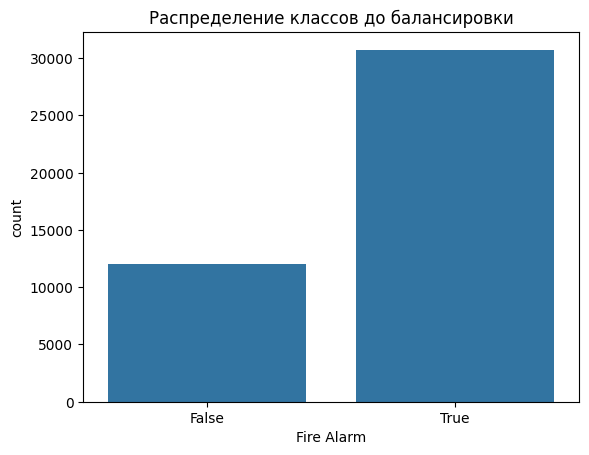

In [6]:
sns.countplot(x=y)
plt.title("Распределение классов до балансировки")
plt.show()

Fire Alarm
False    30728
True     30728
Name: count, dtype: int64


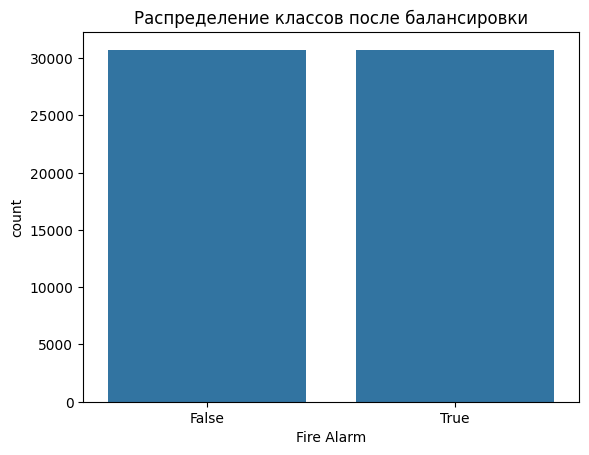

In [7]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(y_resampled.value_counts())

sns.countplot(x=y_resampled)
plt.title("Распределение классов после балансировки")
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled
)

print("\nРазмеры выборок (Hold-out):")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


Размеры выборок (Hold-out):
X_train: (43019, 12)
X_test: (18437, 12)
y_train: (43019,)
y_test: (18437,)


In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

log_reg_model = LogisticRegression(max_iter=3000)
cv_scores = cross_val_score(log_reg_model, X_resampled, y_resampled, cv=kf, scoring='accuracy')

print(f"\nОценки точности на 5 фолдах (K-Fold): {cv_scores}")
print(f"Средняя точность по кросс-валидации: {np.mean(cv_scores):.4f}")


Оценки точности на 5 фолдах (K-Fold): [0.94297104 0.94361728 0.94207143 0.94369864 0.94142055]
Средняя точность по кросс-валидации: 0.9428


In [10]:
def confusion_matrix_custom(y_true, y_pred):
    true_positive = np.sum((y_true == True) & (y_pred == True))
    false_positive = np.sum((y_true == False) & (y_pred == True))
    false_negative = np.sum((y_true == True) & (y_pred == False))
    true_negative = np.sum((y_true == False) & (y_pred == False))
    return np.array([[true_negative, false_positive],
                     [false_negative, true_positive]])

def accuracy_custom(y_true, y_pred):
    cm = confusion_matrix_custom(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    return (TP + TN) / (TP + TN + FP + FN)

def precision_custom(y_true, y_pred, pos_label=True):
    cm = confusion_matrix_custom(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    if (TP + FP) == 0:
        return 0.0
    return TP / (TP + FP)

def recall_custom(y_true, y_pred, pos_label=True):
    cm = confusion_matrix_custom(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    if (TP + FN) == 0:
        return 0.0
    return TP / (TP + FN)

def f1_score_custom(y_true, y_pred, pos_label=True):
    p = precision_custom(y_true, y_pred, pos_label)
    r = recall_custom(y_true, y_pred, pos_label)
    if (p + r) == 0:
        return 0.0
    return 2 * (p * r) / (p + r)

In [11]:
class CustomKNN:
    def __init__(self, k=3):
        self.k = k

    def _euclidean_distance(self, p1, p2):
        return np.sqrt(np.sum((p1 - p2)**2))

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def _predict_single(self, x_test):
        distances = [self._euclidean_distance(x_test, x_train) for x_train in self.X_train]
        
        # Найти k ближайших соседей (их индексы)
        k_indices = np.argsort(distances)[:self.k]
        
        # Получить метки этих соседей
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        
        # Вернуть наиболее частую метку
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

    def predict(self, X_test):
        if not isinstance(self.X_train, np.ndarray):
            self.X_train = self.X_train.values
        if not isinstance(self.y_train, np.ndarray):
            self.y_train = self.y_train.values
        if not isinstance(X_test, np.ndarray):
            X_test = X_test.values
            
        predictions = [self._predict_single(x_test) for x_test in X_test]
        return np.array(predictions)

In [12]:
X_train_small, _, y_train_small, _ = train_test_split(X_train, y_train, train_size=0.125, random_state=42, stratify=y_train)

In [ ]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "kNN (k=5, euclidean)": KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    "Naive Bayes": GaussianNB(),
    "SVM (Linear)": SVC(kernel='linear', probability=True, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
    "SVM (Poly)": SVC(kernel='poly', probability=True, random_state=42),
    "Custom kNN (k=5)": CustomKNN(k=5) 
}

results = {}

for name, clf in classifiers.items():
    print(f"--- Обучение и оценка модели: {name} ---")
    
    clf.fit(X_train_small, y_train_small)
    
    y_pred = clf.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    if hasattr(clf, "predict_proba"):
        y_proba = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        auc = "N/A"
    
    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'AUC': auc,
        'fpr': None, 'tpr': None
    }
    
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        results[name]['fpr'] = fpr
        results[name]['tpr'] = tpr

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    if auc != "N/A":
        print(f"ROC AUC: {auc:.4f}")
    
    print("Матрица ошибок (scikit-learn):\n", cm)
    
    if name == "Logistic Regression":
        print("\n--- Проверка пользовательских метрик ---")
        print("Матрица ошибок (custom):\n", confusion_matrix_custom(y_test, y_pred))
        print(f"Accuracy (custom): {accuracy_custom(y_test, y_pred):.4f}")
        print(f"Precision (custom): {precision_custom(y_test, y_pred):.4f}")
        print(f"Recall (custom): {recall_custom(y_test, y_pred):.4f}")
        print(f"F1-Score (custom): {f1_score_custom(y_test, y_pred):.4f}")
    
    print("\n")

--- Обучение и оценка модели: Logistic Regression ---


c:\Users\IronSmail\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.9439
Precision: 0.9669
Recall: 0.9193
F1-Score: 0.9425
ROC AUC: 0.9841
Матрица ошибок (scikit-learn):
 [[8929  290]
 [ 744 8474]]

--- Проверка пользовательских метрик ---
Матрица ошибок (custom):
 [[8929  290]
 [ 744 8474]]
Accuracy (custom): 0.9439
Precision (custom): 0.9669
Recall (custom): 0.9193
F1-Score (custom): 0.9425


--- Обучение и оценка модели: kNN (k=5, euclidean) ---
Accuracy: 0.9982
Precision: 0.9988
Recall: 0.9975
F1-Score: 0.9982
ROC AUC: 0.9998
Матрица ошибок (scikit-learn):
 [[9208   11]
 [  23 9195]]


--- Обучение и оценка модели: Naive Bayes ---
Accuracy: 0.8763
Precision: 0.9852
Recall: 0.7640
F1-Score: 0.8606
ROC AUC: 0.9812
Матрица ошибок (scikit-learn):
 [[9113  106]
 [2175 7043]]


--- Обучение и оценка модели: SVM (Linear) ---


Ошибки первого и второго рода

Матрица ошибок имеет вид: [[TN, FP], [FN, TP]]

- N (True Negative): Модель правильно предсказала отсутствие пожара.
- FP (False Positive) - Ошибка I рода: Модель предсказала пожар, но его не было (ложная тревога).
- FN (False Negative) - Ошибка II рода: Модель предсказала отсутствие пожара, но он был. Это самый опасный тип ошибки для данной задачи!
- TP (True Positive): Модель правильно предсказала наличие пожара.

В контексте нашей задачи, мы хотим минимизировать FN (ошибки II рода), так как пропуск реального пожара может привести к катастрофическим последствиям.

In [ ]:
# 1. GridSearchCV
print("--- GridSearchCV ---")
param_grid = {'C': [0.1, 1, 10], 'gamma': [1, 0.1, 0.01], 'kernel': ['rbf']}
grid = GridSearchCV(SVC(probability=True), param_grid, refit=True, verbose=0, cv=3)
grid.fit(X_train_small, y_train_small)
print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучшая оценка на кросс-валидации: {grid.best_score_:.4f}")

In [ ]:
# 2. RandomizedSearchCV
print("\n--- RandomizedSearchCV ---")
param_dist = {'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001]}
random_search = RandomizedSearchCV(SVC(kernel='rbf', probability=True), param_distributions=param_dist, n_iter=5, cv=3, random_state=42)
random_search.fit(X_train_small, y_train_small)
print(f"Лучшие параметры: {random_search.best_params_}")
print(f"Лучшая оценка на кросс-валидации: {random_search.best_score_:.4f}")

In [ ]:
# 3. Optuna
print("\n--- Optuna ---")
def objective(trial):
    C = trial.suggest_loguniform('C', 1e-2, 1e2)
    gamma = trial.suggest_loguniform('gamma', 1e-4, 1e-1)
    
    svc = SVC(C=C, gamma=gamma, kernel='rbf', random_state=42)
    score = cross_val_score(svc, X_train_small, y_train_small, n_jobs=-1, cv=3).mean()
    return score


In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20) 
print(f"Лучшие параметры: {study.best_trial.params}")
print(f"Лучшее значение (accuracy): {study.best_value:.4f}")

In [ ]:
k_range = range(1, 20)
accuracy_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_small, y_train_small)
    y_pred = knn.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracy_scores, marker='o')
plt.title('Влияние k на точность модели kNN')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Точность (Accuracy)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(12, 10))
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')

for name, res in results.items():
    if res['fpr'] is not None and res['tpr'] is not None:
        auc_score = res['AUC']
        plt.plot(res['fpr'], res['tpr'], label=f"{name} (AUC = {auc_score:.3f})")

plt.title('ROC-кривые для моделей классификации')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
results_df = pd.DataFrame(results).T.drop(['fpr', 'tpr'], axis=1)
print("--- Итоговая таблица метрик для всех моделей ---")
print(results_df.sort_values(by='F1-Score', ascending=False))